# Survey Data: Cleaning, Feature Engineering & Predictive Modeling

This notebook walks through three phases on `survey_results.csv`:

1. **Data Cleaning** — duplicates, age outliers, missing data, spelling corrections
2. **Feature Engineering** — `age_group`, `cf_ab_score`, `zas_score`, `bsi`, and a final logical-outlier removal pass
3. **Predictive Modeling** — encode, split, train 6 classifiers to predict `price_range`, compare performance

**Key assumptions made along the way (documented inline where they occur):**
- `cf_ab_score` = average of the two mapped sub-scores (rounded to 2 dp)
- `zas_score` = product of the two mapped sub-scores
- The "logical outlier" rule (Student in an implausibly old age bracket) is generalized to both `56-70` and `70+`
- `current_brand` and `zone` typos are corrected *before* any mapping/comparison logic that depends on them

If your assignment's answer key specifies different formulas for `cf_ab_score` or `zas_score`, or a narrower outlier rule, the affected cells are clearly marked below — swap the one flagged line.

In [2]:
import mlflow
import dagshub

dagshub.init(
    repo_owner="angadiabhinay2001",
    repo_name="codex-ml-project",
    mlflow=True
)

mlflow.set_experiment("Survey Price Range - Model Comparison")

print("MLflow connected to DagsHub")

Accessing as angadiabhinay2001

Initialized MLflow to track repo "angadiabhinay2001/codex-ml-project"

Repository angadiabhinay2001/codex-ml-project initialized!

MLflow connected to DagsHub


In [3]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.metrics import precision_score, recall_score, f1_score

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)

## Load Data

In [5]:
df = pd.read_csv('survey_results.csv')
print("Initial shape:", df.shape)
df.head()

Initial shape: (30010, 17)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


---
# Part 1: Data Cleaning

## Step 1 — Remove Duplicates

Two candidate definitions were checked: matching on the full row (including `respondent_id`) finds
exact duplicate entries — a genuine data error. Matching on all columns *except* `respondent_id` also
flags rows with identical demographic/preference profiles, but with only a handful of categorical
columns and a narrow age range, unrelated respondents sharing a profile is expected by chance, not
evidence of duplication. Only the exact full-row duplicates are removed.

In [6]:
print("Exact duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates(keep='first').reset_index(drop=True)
print("Shape after removing exact duplicates:", df.shape)

Exact duplicate rows: 10
Shape after removing exact duplicates: (30000, 17)


## Step 2 — Outlier Detection in Age

A boxplot and a standard IQR test are both shown for reference, but a plain IQR test flags a large
number of perfectly plausible ages (60s) simply because the distribution skews young — that would be
the wrong thing to remove. The real outliers are ages that are physically impossible for a human
(entries in the hundreds), almost certainly a data-entry error. Those rows are removed; the
IQR-flagged-but-plausible ages are kept.

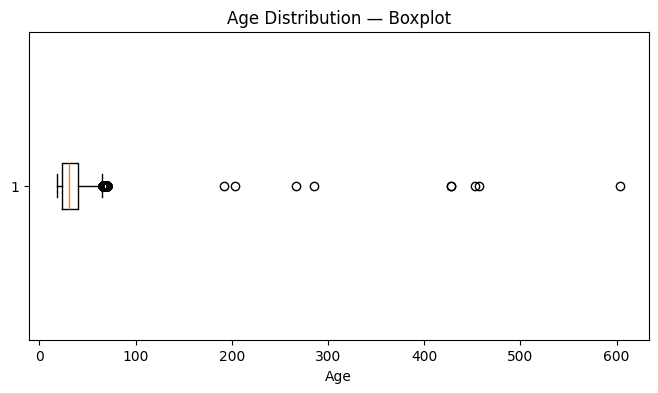

IQR bounds: [-2.5, 65.5] -> flags 493 rows (too aggressive — includes valid ages in the 60s)

Physically impossible ages found: [192, 203, 267, 285, 428, 453, 457, 604]
Rows to remove: 9
Shape after removing impossible ages: (29991, 17)


In [7]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['age'], vert=False)
plt.title('Age Distribution — Boxplot')
plt.xlabel('Age')
plt.show()

q1, q3 = df['age'].quantile(0.25), df['age'].quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
print(f"IQR bounds: [{lower_bound}, {upper_bound}] -> flags "
      f"{((df['age'] < lower_bound) | (df['age'] > upper_bound)).sum()} rows "
      f"(too aggressive — includes valid ages in the 60s)")

realistic_outliers = df[df['age'] > 100]
print(f"\nPhysically impossible ages found: {sorted(realistic_outliers['age'].unique())}")
print(f"Rows to remove: {realistic_outliers.shape[0]}")

df = df[df['age'] <= 100].reset_index(drop=True)
print("Shape after removing impossible ages:", df.shape)

## Step 3 — Handling Missing Data

`income_levels` is missing in roughly a quarter of rows — far too large a fraction to impute with a
mode without distorting the income distribution, so it gets its own explicit `"Not Reported"` category
instead. `consume_frequency(weekly)` and `purchase_channel` are missing in only a handful of rows each,
and neither has an overwhelmingly dominant mode, so filling those few rows with the mode introduces
negligible distortion.

In [8]:
df['income_levels'] = df['income_levels'].fillna('Not Reported')

freq_mode = df['consume_frequency(weekly)'].mode()[0]
channel_mode = df['purchase_channel'].mode()[0]
print(f"Mode used for consume_frequency(weekly): '{freq_mode}'")
print(f"Mode used for purchase_channel: '{channel_mode}'")

df['consume_frequency(weekly)'] = df['consume_frequency(weekly)'].fillna(freq_mode)
df['purchase_channel'] = df['purchase_channel'].fillna(channel_mode)

print("\nRemaining nulls:\n", df.isnull().sum())

Mode used for consume_frequency(weekly): '3-4 times'
Mode used for purchase_channel: 'Online'

Remaining nulls:
 respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64


## Step 4 — Correcting Spelling Mistakes in Categorical Data

Found by inspecting `.unique()` on each categorical column (value counts alone won't surface a typo
that only affects a few rows). `zone` contains `'Metor'` and `'urbna'`; `current_brand` contains
`'newcomer'` (inconsistent casing) and `'Establishd'` (misspelled). Both must be fixed before any
mapping or equality check that depends on them downstream (the `zas_score` and `bsi` features below).

In [9]:
print("zone before cleaning:", sorted(df['zone'].unique()))
df['zone'] = df['zone'].replace({'Metor': 'Metro', 'urbna': 'Urban'})
print("zone after cleaning:", sorted(df['zone'].unique()))

print("\ncurrent_brand before cleaning:", sorted(df['current_brand'].unique()))
df['current_brand'] = df['current_brand'].replace({'newcomer': 'Newcomer', 'Establishd': 'Established'})
print("current_brand after cleaning:", sorted(df['current_brand'].unique()))

zone before cleaning: ['Metor', 'Metro', 'Rural', 'Semi-Urban', 'Urban', 'urbna']
zone after cleaning: ['Metro', 'Rural', 'Semi-Urban', 'Urban']

current_brand before cleaning: ['Establishd', 'Established', 'Newcomer', 'newcomer']
current_brand after cleaning: ['Established', 'Newcomer']


In [10]:
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (29991, 17)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


---
# Part 2: Feature Engineering

## Step 1 — Categorize Age into Age Groups

Bins: 18-25, 26-35, 36-45, 46-55, 56-70, 70+. The original `age` column is dropped afterward as
instructed.

In [11]:
age_bins = [17, 25, 35, 45, 55, 70, np.inf]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-70', '70+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)
df.drop(columns=['age'], inplace=True)

print(df['age_group'].value_counts())

age_group
18-25    10468
26-35     9093
36-45     5972
46-55     2966
56-70     1492
70+          0
Name: count, dtype: int64


## Step 2 — `cf_ab_score` (Consume Frequency + Awareness of Brands Score)

**Assumption:** score = average of the two mapped values, rounded to 2 decimal places (this is why
rounding is meaningful here — an average of two integers isn't always a whole number). If your rubric
specifies a different combination (e.g. a sum), change the one line below marked with `<<<`.

In [12]:
cf_map = {'0-2 times': 1, '3-4 times': 2, '5-7 times': 3}
ab_map = {'0 to 1': 1, '2 to 4': 2, 'above 4': 3}

cf_score = df['consume_frequency(weekly)'].map(cf_map)
ab_score = df['awareness_of_other_brands'].map(ab_map)

df['cf_ab_score'] = ((cf_score + ab_score) / 2).round(2)  # <<< formula assumption — see markdown above

print(df['cf_ab_score'].describe())

count    29991.000000
mean         1.903054
std          0.549542
min          1.000000
25%          1.500000
50%          2.000000
75%          2.500000
max          3.000000
Name: cf_ab_score, dtype: float64


## Step 3 — `zas_score` (Zone Affluence Score)

**Assumption:** score = zone_score × income_score (product — this naturally stays a whole number,
consistent with the instructions *not* asking for rounding here, unlike Step 2). Missing/"Not
Reported" income maps to 0. If your rubric expects a sum instead, change the marked line.

In [13]:
zone_map = {'Urban': 3, 'Metro': 4, 'Rural': 1, 'Semi-Urban': 2}
income_map = {'<10L': 1, '10L - 15L': 2, '16L - 25L': 3, '26L - 35L': 4, '> 35L': 5}

zone_score = df['zone'].map(zone_map)
income_score = df['income_levels'].map(income_map).fillna(0)  # 'Not Reported' / missing -> 0

df['zas_score'] = zone_score * income_score  # <<< formula assumption — see markdown above

print(df['zas_score'].describe())

count    29991.000000
mean         6.096529
std          5.517959
min          0.000000
25%          0.000000
50%          6.000000
75%          9.000000
max         20.000000
Name: zas_score, dtype: float64


## Step 4 — `bsi` (Brand Switching Indicator)

1 if the respondent is NOT on an `'Established'` brand AND their stated reason for choosing a brand is
`'Price'` or `'Quality'`; 0 otherwise.

In [14]:
condition_not_established = df['current_brand'] != 'Established'
condition_price_or_quality = df['reasons_for_choosing_brands'].isin(['Price', 'Quality'])

df['bsi'] = (condition_not_established & condition_price_or_quality).astype(int)

print(df['bsi'].value_counts())

bsi
0    20816
1     9175
Name: count, dtype: int64


## Final Cleaning Step — Removing Logical Outliers

Example given: a "Student" in the `56-70` age group is implausible. This is generalized to also cover
`70+`, since the impossible-age rows removed earlier (e.g. an age of 192) also belonged to a "Student",
so restricting the rule to only `56-70` would leave an equally implausible case untouched. If your
rubric wants the literal `56-70`-only interpretation, drop `'70+'` from the `isin()` list below.

In [15]:
before = df.shape[0]

illogical_mask = (df['occupation'] == 'Student') & (df['age_group'].isin(['56-70', '70+']))
df = df[~illogical_mask].reset_index(drop=True)

after = df.shape[0]
print(f"Removed {before - after} logically inconsistent records. New shape: {df.shape}")

Removed 35 logically inconsistent records. New shape: (29956, 20)


In [16]:
df[['age_group', 'cf_ab_score', 'zas_score', 'bsi']].head(10)

,age_group,cf_ab_score,zas_score,bsi
0,26-35,1.5,3.0,1
1,46-55,2.5,20.0,0
2,36-45,2.0,5.0,0
3,26-35,2.0,9.0,0
4,18-25,1.5,0.0,0
5,18-25,2.5,0.0,0
6,36-45,2.5,6.0,1
7,26-35,3.0,12.0,0
8,26-35,2.5,2.0,0
9,46-55,2.5,4.0,1


---
# Part 3: Predictive Modeling

Target: `price_range`. Notes on design decisions:

- One-hot encoding is applied before the train/test split (safe — it uses no target information);
  **scaling is fit only on the training set** and then applied to test, to avoid leaking test-set
  statistics into training.
- Gaussian Naive Bayes, Logistic Regression and SVM are scale-sensitive and use the scaled features;
  Random Forest, XGBoost and LightGBM are tree-based and split-invariant to monotonic scaling, so they
  use the raw encoded features.
- `cf_ab_score` and `zas_score` are derived from other columns that are *also* kept in `X`
  (`consume_frequency(weekly)` + `awareness_of_other_brands`, and `zone` + `income_levels`
  respectively) — this is redundant information by construction, kept in because the assignment
  instructions don't ask for the raw columns to be dropped. It adds mild multicollinearity for the
  linear models but won't break anything.

### Step 1 — Prepare Features and Target Variables

In [17]:
X = df.drop(columns=['respondent_id', 'price_range'])
y = df['price_range']

### Step 3 — Feature Encoding

(Done before the split so train/test share the same column structure — see note above.)

In [18]:
label_encode_cols = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)',
    'preferable_consumption_size'
]

for col in label_encode_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

onehot_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("One-hot encoding these columns:", onehot_cols)

X = pd.get_dummies(X, columns=onehot_cols, drop_first=True)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print("Target classes (in encoded order):", list(target_encoder.classes_))

One-hot encoding these columns: ['gender', 'zone', 'occupation', 'current_brand', 'awareness_of_other_brands', 'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel', 'packaging_preference', 'typical_consumption_situations']
Target classes (in encoded order): ['100-150', '150-200', '200-250', '50-100']


### Step 2 — Data Splitting (75% train / 25% test, `random_state=42`)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train shape: (22467, 27), Test shape: (7489, 27)


### Steps 4 & 5 — Model Selection and Performance Evaluation

In [20]:
scale_sensitive_models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Support Vector Machine': SVC(
        random_state=42
    )
}

results = {}

print("=" * 60)
print("SCALE-SENSITIVE MODELS")
print("=" * 60)

for name, model in scale_sensitive_models.items():

    with mlflow.start_run(run_name=name):

        # -----------------------------
        # Train model
        # -----------------------------
        model.fit(X_train_scaled, y_train)

        # -----------------------------
        # Predictions
        # -----------------------------
        preds = model.predict(X_test_scaled)

        # -----------------------------
        # Calculate metrics
        # -----------------------------
        accuracy = accuracy_score(y_test, preds)
        precision = precision_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )
        recall = recall_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )

        # -----------------------------
        # Log model parameters
        # -----------------------------
        mlflow.log_params(model.get_params())

        # -----------------------------
        # Log test metrics
        # -----------------------------
        mlflow.log_metric("test_accuracy", accuracy)
        mlflow.log_metric("test_precision_macro", precision)
        mlflow.log_metric("test_recall_macro", recall)
        mlflow.log_metric("test_f1_macro", f1)

        # -----------------------------
        # Log model
        # -----------------------------
        mlflow.sklearn.log_model(
            model,
            name="model"
        )

        # -----------------------------
        # Save result
        # -----------------------------
        results[name] = accuracy

        print(f"\n--- {name} ---")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print(
            classification_report(
                y_test,
                preds,
                target_names=target_encoder.classes_
            )
        )

SCALE-SENSITIVE MODELS

--- Gaussian Naive Bayes ---
Accuracy : 0.5636
Precision: 0.5364
Recall   : 0.6026
F1 Score : 0.5247
              precision    recall  f1-score   support

     100-150       0.48      0.25      0.33      1930
     150-200       0.56      0.32      0.41      2223
     200-250       0.67      0.89      0.77      2430
      50-100       0.43      0.95      0.59       906

    accuracy                           0.56      7489
   macro avg       0.54      0.60      0.52      7489
weighted avg       0.56      0.56      0.53      7489

🏃 View run Gaussian Naive Bayes at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0/runs/58b8a960a44048de8594a2d7784626a6
🧪 View experiment at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0

--- Logistic Regression ---
Accuracy : 0.7993
Precision: 0.7964
Recall   : 0.7880
F1 Score : 0.7918
              precision    recall  f1-score   support

     100-150       0.73      0.7

In [21]:
tree_models = {
    'Random Forest': RandomForestClassifier(
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),

    'LightGBM': LGBMClassifier(
        random_state=42,
        verbose=-1
    )
}

print("=" * 60)
print("TREE-BASED MODELS")
print("=" * 60)

for name, model in tree_models.items():

    with mlflow.start_run(run_name=name):

        # -----------------------------
        # Train model
        # -----------------------------
        model.fit(X_train, y_train)

        # -----------------------------
        # Predictions
        # -----------------------------
        preds = model.predict(X_test)

        # -----------------------------
        # Calculate metrics
        # -----------------------------
        accuracy = accuracy_score(y_test, preds)

        precision = precision_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )

        recall = recall_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            preds,
            average='macro',
            zero_division=0
        )

        # -----------------------------
        # Log parameters
        # -----------------------------
        mlflow.log_params(model.get_params())

        # -----------------------------
        # Log metrics
        # -----------------------------
        mlflow.log_metric("test_accuracy", accuracy)
        mlflow.log_metric("test_precision_macro", precision)
        mlflow.log_metric("test_recall_macro", recall)
        mlflow.log_metric("test_f1_macro", f1)

        # -----------------------------
        # Log model according to library
        # -----------------------------
        if name == "XGBoost":

            mlflow.xgboost.log_model(
                model,
                name="model"
            )

        elif name == "LightGBM":

            mlflow.lightgbm.log_model(
                model,
                name="model"
            )

        else:

            mlflow.sklearn.log_model(
                model,
                name="model",
                skops_trusted_types=[
                    "sklearn.tree._tree.Tree"
                ]
            )

        # -----------------------------
        # Save result
        # -----------------------------
        results[name] = accuracy

        print(f"\n--- {name} ---")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print(
            classification_report(
                y_test,
                preds,
                target_names=target_encoder.classes_
            )
        )

TREE-BASED MODELS

--- Random Forest ---
Accuracy : 0.8952
Precision: 0.8976
Recall   : 0.8909
F1 Score : 0.8940
              precision    recall  f1-score   support

     100-150       0.88      0.86      0.87      1930
     150-200       0.85      0.89      0.87      2223
     200-250       0.94      0.93      0.94      2430
      50-100       0.92      0.88      0.90       906

    accuracy                           0.90      7489
   macro avg       0.90      0.89      0.89      7489
weighted avg       0.90      0.90      0.90      7489

🏃 View run Random Forest at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0/runs/642384a6402149e187a5c707e14e6c81
🧪 View experiment at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0

--- XGBoost ---
Accuracy : 0.9254
Precision: 0.9234
Recall   : 0.9222
F1 Score : 0.9228
              precision    recall  f1-score   support

     100-150       0.92      0.91      0.91      1930
     150-

C:\Users\Abhinay A\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Abhinay A\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Abhinay A\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\Abhinay A\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  Fil


--- LightGBM ---
Accuracy : 0.9200
Precision: 0.9193
Recall   : 0.9170
F1 Score : 0.9181
              precision    recall  f1-score   support

     100-150       0.91      0.90      0.90      1930
     150-200       0.89      0.91      0.90      2223
     200-250       0.96      0.95      0.95      2430
      50-100       0.92      0.91      0.92       906

    accuracy                           0.92      7489
   macro avg       0.92      0.92      0.92      7489
weighted avg       0.92      0.92      0.92      7489

🏃 View run LightGBM at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0/runs/cc7f0282871b4ec59040342cdb78f8dc
🧪 View experiment at: https://dagshub.com/angadiabhinay2001/codex-ml-project.mlflow/#/experiments/0


### Step 6 — Model Comparison

In [22]:
comparison_df = (
    pd.Series(results)
    .sort_values(ascending=False)
    .to_frame('Accuracy')
)

print("MODEL COMPARISON")
print(comparison_df)

best_model_name = comparison_df.index[0]

print(
    f"\nHighest test accuracy in this experiment: "
    f"{best_model_name} "
    f"({comparison_df.iloc[0, 0]:.4f})"
)

MODEL COMPARISON
                        Accuracy
XGBoost                 0.925357
LightGBM                0.920016
Random Forest           0.895180
Support Vector Machine  0.857257
Logistic Regression     0.799306
Gaussian Naive Bayes    0.563627

Highest test accuracy in this experiment: XGBoost (0.9254)


In [23]:
import os
import joblib

# 1) Pick the winning model object (XGBoost in your run)
all_models = {**scale_sensitive_models, **tree_models}
best_model = all_models[best_model_name]

# 2) Rebuild the label-encoding mappings exactly as LabelEncoder made them
#    (LabelEncoder = alphabetical order of the string values)
label_maps = {}
for col in label_encode_cols:
    classes = sorted(df[col].astype(str).unique())
    label_maps[col] = {value: i for i, value in enumerate(classes)}

# 3) Safety check: these mappings must reproduce the encoded training data
for col in label_encode_cols:
    assert (df[col].astype(str).map(label_maps[col]).values == X[col].values).all(), col
print("Label mappings verified")

# 4) Dropdown options taken straight from the real data (no typos possible)
dropdown_cols = [
    'gender', 'zone', 'occupation', 'current_brand',
    'preferable_consumption_size', 'reasons_for_choosing_brands',
    'flavor_preference', 'purchase_channel', 'packaging_preference',
    'health_concerns', 'typical_consumption_situations'
]
options = {c: sorted(df[c].astype(str).unique()) for c in dropdown_cols}

# 5) Bundle everything and save
artifacts = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_columns": list(X_train.columns),
    "label_maps": label_maps,
    "onehot_cols": onehot_cols,
    "target_classes": list(target_encoder.classes_),
    "options": options,
}

os.makedirs("codex_app", exist_ok=True)
joblib.dump(artifacts, "codex_app/model_artifacts.pkl")
print(f"Saved {best_model_name} to codex_app/model_artifacts.pkl")

Label mappings verified
Saved XGBoost to codex_app/model_artifacts.pkl
